# Case I

This notebook reproduces the Case I plots seen in Section 4.1 of the paper.

The notebook contains:

1. A width sweep over the density network $W_u \in \{8,16,32,64,128\}$ at fixed diffusion width $W_D = 2$ across $ES \in \{1000, 2000, 3000\}$.
2. Diffusion-function comparisons for $W_u=64$ from the first sweep.
3. A width sweep over the density network $W_u \in \{8,16,32,64,128\}$ at fixed $ES = 2000$ across diffusion network widths $W_D \in \{1,2,4\}$

*It produces plots for Figs. 5 and 7 in the paper.*


In [2]:
import os
import sys
from pathlib import Path
import numpy as np

PROJECT_ROOT = next(
    path
    for path in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
    if (path / "Training").is_dir()
)
project_root_str = str(PROJECT_ROOT)
if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

from Training.JN.notebook_helpers.notebook_data import build_catalog, load_data_object, load_original_data
from Training.JN.notebook_helpers.notebook_config import (
    BCbool,
    BNdataLossFuncLabel,
    D_one_param_bool,
    binn_batch_size,
    binn_lr,
    binn_model_num,
    binn_rel_save_thresh,
    binn_rel_update_thresh,
    binnDevice,
    binnGenerateIndicesLabel,
    binnVF,
)
from Training.JN.notebook_helpers.notebook_models import (
    active_constraint_settings,
    build_model_catalog,
    build_model_path,
    filter_model_catalog,
    load_requested_models,
    summarize_requested_models,
)
from Training.JN.notebook_helpers.notebook_setup import bootstrap_notebook, register_notebook_pickle_globals

paths = bootstrap_notebook(PROJECT_ROOT)
PROJECT_ROOT = paths.project_root
JN_ROOT = paths.notebook_root

register_notebook_pickle_globals()

from paper_helpers import (
    metric_u_grid,
    scale_function_by_percent_error,
    plot_diff_mse_lst,
    plot_eval_D_multi_gray,
    plot_final_loss_lst,
    plot_total_run_times_lst,
    plot_initial_condition_1d,
    plot_running_min_MSE_diff_loss_broken_x_log_lst,
    plot_running_min_loss_component_broken_x_log_lst,
    symbolic_from_function,
)


## 1. Load the Case I data

We first recover the simulated reaction-diffusion dataset used throughout the notebook. The spatial and temporal grids follow [Lagergren et al. (2020)](https://doi.org/10.1371/journal.pcbi.1008462), and the cell below verifies that the Case I data object exists on disk before any model analysis begins.


MSE between u and u_clean: 0.0
ABS between u and u_clean [cells]: 0.0
ABS (%) between u and u_clean: 0.0


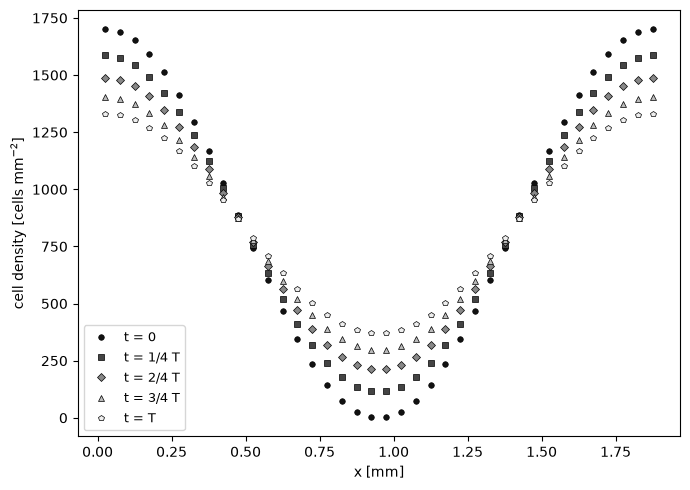

In [3]:
DATA_ROOT = paths.data_root

original_data_obj = load_original_data(DATA_ROOT)
x_grid = original_data_obj.x
t_grid = original_data_obj.t
CASE1_CARRYING_CAPACITY = 1  # Densities are normalized so the effective carrying capacity is 1.
REALISTIC_CARRYING_CAPACITY = 1700 # cells/mm^2
data_df = build_catalog(DATA_ROOT, target_filename="data_obj.npy")

CASE1_DATA_CONFIG = {
    "dataX1num": len(x_grid),
    "dataX2num": 1,
    "dataTnum": len(t_grid),
    "dataK": CASE1_CARRYING_CAPACITY,
    "dataICLabel": "cos",
    "dataDiffLabel": "const",
    "dataGrowLabel": "zero",
    "dataGamma": 0,
    "dataNoisePercent": 0,
    "dataNoiseSeed": 0,
}

data_obj, _ = load_data_object(
    CASE1_DATA_CONFIG,
    DATA_ROOT,
    data_df=data_df,
)
plot_initial_condition_1d(data_obj)


## 2. Build the Case I model catalogue & form helper functions for model loading and plotting



### 2.1. Catalogue trained model

Next we catalogue all saved BINN checkpoints under `Training/binn`, filter them to the fixed assumptions used in Case I, and display the subset that should support the figure sweeps below.


The varying dimensions in this notebook are `binnES`, `binnDsize`, `binnUsize`, and `binnTVsplitSeed`; everything else is held fixed for Case I.


In [4]:
BINN_ROOT = paths.binn_root
binn_df = build_model_catalog(BINN_ROOT)


#  ===================================  1D specific settings =================================
CASE1_NUM_PDE_SAMPLES = 1000

# ====================== Diffusion only, no growth specific settings =========================
ALL_CONSTRAINTS = True                         # Enforce bounding and monotonicity constraints
CONSTRAINT_TUPLE = (True, True, False, False)  # Latter two constraints not needed 
#                                               (G is absent so no need for G-bound or G-mono)
CONSTRAINT_WEIGHTS = {
    "D_bound_weight": 0,
    "D_mono_weight": 1e1
}
CONSTRAINT_BOUNDS = {
    "D_bound": (0, 0.1)
}
FIXED_G_WIDTH = None
# =============================================================================================



CASE1_SHARED_MODEL_FILTERS = {
    "binnVF": binnVF,
    "binnGenerateIndicesLabel": binnGenerateIndicesLabel,
    "DoneParamBool": D_one_param_bool,
    "binnDevice": binnDevice,
    "allConstraints": ALL_CONSTRAINTS,
    "BCbool": BCbool,
    "numPDEsamples": CASE1_NUM_PDE_SAMPLES,
    "binnLR": binn_lr,
    "binnBatchSize": binn_batch_size,
    "binnRelUpdateThresh": binn_rel_update_thresh,
    "binnRelSaveThresh": binn_rel_save_thresh,
    "BNdataLossFuncLabel": BNdataLossFuncLabel,
}
if ALL_CONSTRAINTS:
    CASE1_SHARED_MODEL_FILTERS |= active_constraint_settings(
        CONSTRAINT_TUPLE,
        CONSTRAINT_WEIGHTS,
        CONSTRAINT_BOUNDS,
    )

CASE1_FIXED_FILTERS = CASE1_DATA_CONFIG | CASE1_SHARED_MODEL_FILTERS | {
    "binnGsize": FIXED_G_WIDTH,
}

case1_catalog = filter_model_catalog(
    binn_df,
    CASE1_FIXED_FILTERS,
    empty_message="No BINN models were found for the fixed Case I assumptions in this notebook.",
)

CATALOG_COLUMNS = [
    "binnES",
    "binnDsize",
    "binnUsize",
    "binnTVsplitSeed",
    "full_path",
]
case1_catalog = case1_catalog.sort_values(
    ["binnES", "binnDsize", "binnUsize", "binnTVsplitSeed"]
).reset_index(drop=True)
case1_catalog[CATALOG_COLUMNS]


,binnES,binnDsize,binnUsize,binnTVsplitSeed,full_path
0,1000,2,128,0,/Users/willa954/Desktop/Git-personal/Hyperpara...
1,1000,2,128,0,/Users/willa954/Desktop/Git-personal/Hyperpara...
2,1000,2,128,0,/Users/willa954/Desktop/Git-personal/Hyperpara...
3,1000,2,128,1,/Users/willa954/Desktop/Git-personal/Hyperpara...
4,1000,2,128,1,/Users/willa954/Desktop/Git-personal/Hyperpara...
...,...,...,...,...,...
196,3000,2,8,1,/Users/willa954/Desktop/Git-personal/Hyperpara...
197,3000,2,8,1,/Users/willa954/Desktop/Git-personal/Hyperpara...
198,3000,2,8,2,/Users/willa954/Desktop/Git-personal/Hyperpara...
199,3000,2,8,2,/Users/willa954/Desktop/Git-personal/Hyperpara...


### 2.2. Helper functions for loading trained models

In [5]:
def build_model_path_case1(d_width, u_width, split_seed, binn_es):
    return build_model_path(
        BINN_ROOT,
        CASE1_FIXED_FILTERS,
        {
            "binnDsize": d_width,
            "binnUsize": u_width,
            "binnTVsplitSeed": split_seed,
            "binnES": binn_es,
        },
        model_df=case1_catalog,
        model_label=binn_model_num,
    )


def build_requested_case1_models(es_values, d_widths, u_widths, split_seeds):
    return [
        {
            "binnES": binn_es,
            "binnDsize": d_width,
            "binnUsize": u_width,
            "binnTVsplitSeed": split_seed,
            "path": build_model_path_case1(d_width, u_width, split_seed, binn_es),
        }
        for binn_es in es_values
        for d_width in d_widths
        for u_width in u_widths
        for split_seed in split_seeds
    ]


def summarize_case1_model_availability(es_values, d_widths, u_widths, split_seeds):
    requested_models = build_requested_case1_models(
        es_values,
        d_widths,
        u_widths,
        split_seeds,
    )
    return summarize_requested_models(
        requested_models,
        label_keys=["binnES", "binnDsize", "binnUsize", "binnTVsplitSeed"],
    )


def load_case1_models(es_values, d_widths, u_widths, split_seeds):
    requested_models = build_requested_case1_models(
        es_values,
        d_widths,
        u_widths,
        split_seeds,
    )
    return load_requested_models(
        requested_models,
        device=binnDevice,
        group_keys=("binnES", "binnDsize", "binnUsize", "binnTVsplitSeed"),
    )


def make_output_dir(*parts):
    output_dir = JN_ROOT / "pngs" / "1D" / "case1"
    for part in parts:
        output_dir = output_dir / str(part)
    os.makedirs(output_dir, exist_ok=True)
    return output_dir


figure_5_dir = make_output_dir("fig5")
figure_7_dir = make_output_dir("fig7")

### 2.3 Shared plotting style

These settings are reused to varying degrees across the results plots


In [6]:
BLUE_COLORS = ["#0033A0", "#1E90FF", "#6699CC", "#A4C8E1", "#D6EAF8"]
D_COLORS = ["#8B2500", "#FF7F0E", "#FDB863", "#FDD9B5", "#FFF1E0"]
linestyles = ["-"] * 5
MARKER_STYLES = ["o"] * 5
MAX_EPOCH = 4e4
BREAK_EPOCH_SHORT = 2e2
LEGEND_SIZE = 18
AXIS_FONTSIZES = {
    "xaxis": 18,
    "xtick_labels": 18,
    "yaxis": 18,
    "ytick_labels":18,
}
X_AXIS = {"min": 0, "max": MAX_EPOCH, "break": BREAK_EPOCH_SHORT}
LEGEND_SIZE_SMALL = 17
RAW_MSES = [0.25, 0.5, 1]

def reference_diffusion_callable(u):
    return data_obj.theta_D * np.ones_like(u)

REFERENCE_U_GRID = metric_u_grid(data_obj)
REFERENCE_DIFF_MSES = [
    scale_function_by_percent_error(reference_diffusion_callable, beta=mse, u_grid=REFERENCE_U_GRID)[1]
    for mse in RAW_MSES
]


def plot_params_from_models(models_dict, colors):
    labels = [str(key) for key in models_dict.keys()]
    return {
        key: [colors[i], linestyles[i], MARKER_STYLES[i], labels[i]]
        for i, key in enumerate(models_dict.keys())
    }


## 3. Sweep A: vary $W_u$ (and $\mathit{ES}$) at fixed $W_D = 2$

This section reproduces the main width sweep over the density network while holding the diffusion network architecture fixed.


In [7]:
#  ======================== Load models  ======================== 
VARY_WU_CONFIG = {
    "es_values": [1000, 2000, 3000],
    "d_widths": [2],
    "u_widths": [8, 16, 32, 64, 128],
    "split_seeds": [0, 1, 2]
}

summarize_case1_model_availability(**VARY_WU_CONFIG)
vary_wu_models_by_es = load_case1_models(**VARY_WU_CONFIG)

Requested model combinations: 45
Already trained model files found: 45
Missing model files: 0


All x-axis labels found (ordered): ['8', '16', '32', '64', '128']


/Users/willa954/Desktop/Git-personal/Hyperparam/binn-hyperparam-selection/Training/JN/paper_helpers/plotting_final_loss.py:216: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax1.grid(bool(grid), axis="y", which="both", linestyle="-", linewidth=0.5, alpha=grid_alpha)


saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/binn-hyperparam-selection/Training/JN/pngs/1D/case1/fig5/plot_a_1


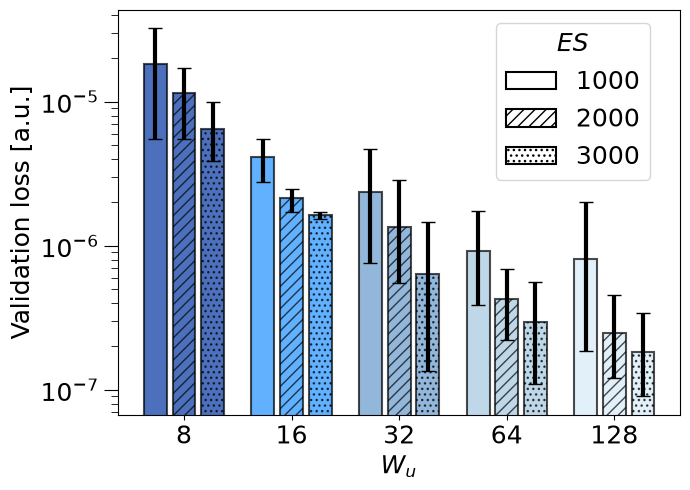

All x-axis labels found (ordered): ['8', '16', '32', '64', '128']
Mean runtime increases between corresponding models across groups:
  1000 -> 2000
    8: 181.925s -> 258.665s (delta +76.740s)
    16: 213.188s -> 359.175s (delta +145.987s)
    32: 274.589s -> 487.687s (delta +213.098s)
    64: 526.098s -> 1076.930s (delta +550.832s)
    128: 824.893s -> 1739.211s (delta +914.319s)
    mean delta: +380.195s
  2000 -> 3000
    8: 258.665s -> 425.391s (delta +166.726s)
    16: 359.175s -> 455.199s (delta +96.024s)
    32: 487.687s -> 889.092s (delta +401.405s)
    64: 1076.930s -> 1580.521s (delta +503.591s)
    128: 1739.211s -> 2240.518s (delta +501.307s)
    mean delta: +333.811s
saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/binn-hyperparam-selection/Training/JN/pngs/1D/case1/fig5/plot_a_2


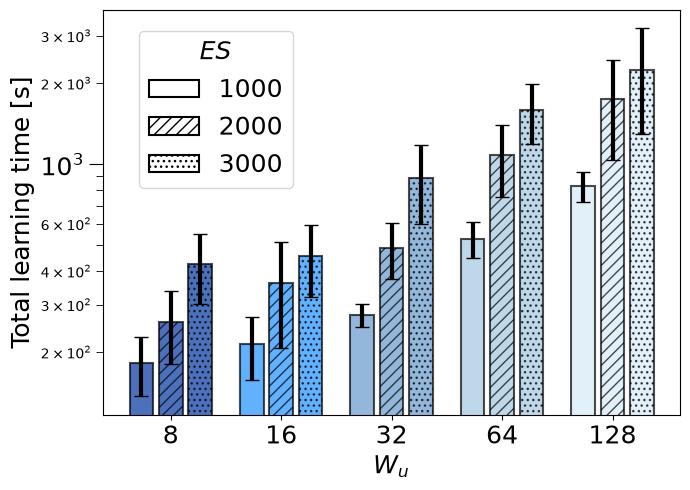

SORTED ['8', '16', '32', '64', '128']


/Users/willa954/Desktop/Git-personal/Hyperparam/binn-hyperparam-selection/Training/JN/paper_helpers/plotting_loss_running_min.py:468: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/binn-hyperparam-selection/Training/JN/pngs/1D/case1/fig5/plot_b


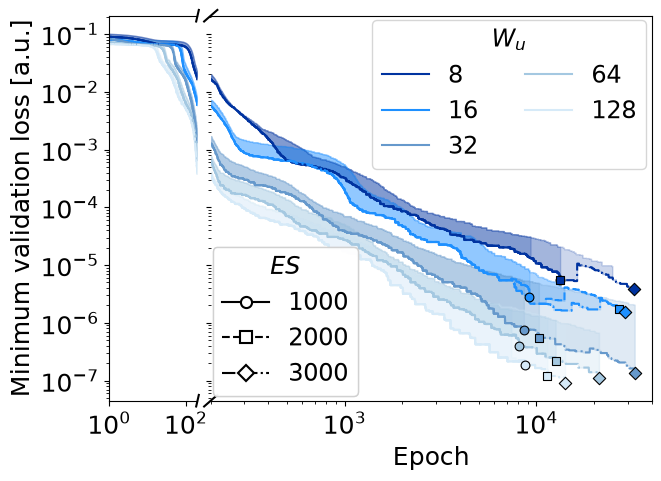

{'name': '/Users/willa954/Desktop/Git-personal/Hyperparam/binn-hyperparam-selection/Training/JN/pngs/1D/case1/fig5/plot_b',
 'legend': {'panel': 2,
  'loc': (0.34, 1.02),
  'loc_upd': (0.36, 0.43),
  'fontsize': 17,
  'ncols': 2,
  'framealpha': 0.8,
  'title': '$W_u$',
  'marker_title': '$ES$'},
 'fill': True,
 'xaxis': {'min': 0, 'max': 40000.0, 'break': 200.0},
 'grid': False,
 'loss_attr': 'val_loss_list',
 'num_runs': 15}

In [8]:
#  ======================== Form plots  ========================
SELECTED_U_WIDTH = 64
SELECTED_D_WIDTH = 2
SELECTED_ES = 1000

selected_es_models = vary_wu_models_by_es[SELECTED_ES]
selected_d_width_models = selected_es_models[SELECTED_D_WIDTH]
models_by_es_for_selected_d_width = [
    vary_wu_models_by_es[binn_es][SELECTED_D_WIDTH]
    for binn_es in VARY_WU_CONFIG["es_values"]
]



primary_plot_params_fig5 = plot_params_from_models(selected_d_width_models, BLUE_COLORS)
primary_plot_params_fig7 = plot_params_from_models(selected_d_width_models, D_COLORS)


# Plot features for figure 5 and figure 7
primary_hatch_patterns_fig5_fig7 = ["", "///", "..."]
primary_legend_title_fig5_fig7 = r"$ES$"
primary_legend_labels_fig5_fig7 = [str(binn_es) for binn_es in VARY_WU_CONFIG["es_values"]]

# Plot features for figure 5
WIDTH_AXIS_LABEL = r"$W_u$"


# First plot of first row of figure 5
# ===================================
plot_final_loss_lst(
    models_by_es_for_selected_d_width,
    plot_params=primary_plot_params_fig5,
    label_list=primary_legend_labels_fig5_fig7,
    name=str(figure_5_dir / "plot_a_1"),
    legend_size=LEGEND_SIZE,
    x_label=WIDTH_AXIS_LABEL,
    axis_fontsizes=AXIS_FONTSIZES,
    hatch_patterns = primary_hatch_patterns_fig5_fig7,
    legend_title = primary_legend_title_fig5_fig7,
    bbox_to_anchor=(0.65, 1),
)


# Second plot of first row of figure 5
# ===================================
plot_total_run_times_lst(
    models_dics_list=models_by_es_for_selected_d_width,
    plot_params=primary_plot_params_fig5,
    label_list=primary_legend_labels_fig5_fig7,
    legend_fontsize=LEGEND_SIZE,
    x_label=WIDTH_AXIS_LABEL,
    name=str(figure_5_dir / "plot_a_2"),
    axis_fontsizes=AXIS_FONTSIZES,
    hatch_patterns = primary_hatch_patterns_fig5_fig7,
    legend_title =primary_legend_title_fig5_fig7,
    legend_pos=(0.35, 0.98),
)

# Third plot of first row of figure 5
# ===================================
plot_settings = {
    "name": str(figure_5_dir / "plot_b"),
    "fill": True,
    "grid": False,
    "legend": {
        "panel": 2,
        "loc": (0.34, 1.02),
        "loc_upd": (0.36, 0.43),
        "fontsize": LEGEND_SIZE_SMALL,
        "ncols": 2,
        
    },
    "xaxis": X_AXIS,
    "fontsizes": AXIS_FONTSIZES,
    "ylabel": "Minimum validation loss [a.u.]",
}

# First plot of second row of figure 5
# ====================================
plot_running_min_loss_component_broken_x_log_lst(
    models_dics_list=models_by_es_for_selected_d_width,
    plot_params=primary_plot_params_fig5,
    plot_settings=plot_settings,
    loss_attr="val_loss_list",
)





/Users/willa954/Desktop/Git-personal/Hyperparam/binn-hyperparam-selection/Training/JN/paper_helpers/plotting_mse_running_min.py:448: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/binn-hyperparam-selection/Training/JN/pngs/1D/case1/fig7/plot_a


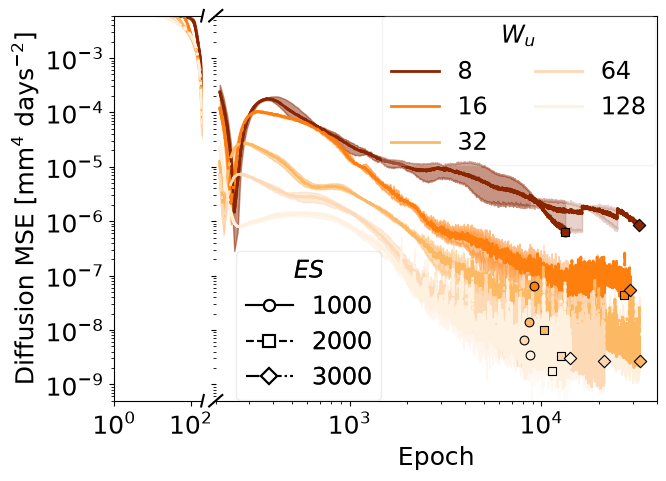

All x-axis labels found (ordered): ['8', '16', '32', '64', '128']
saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/binn-hyperparam-selection/Training/JN/pngs/1D/case1/fig7/plot_b


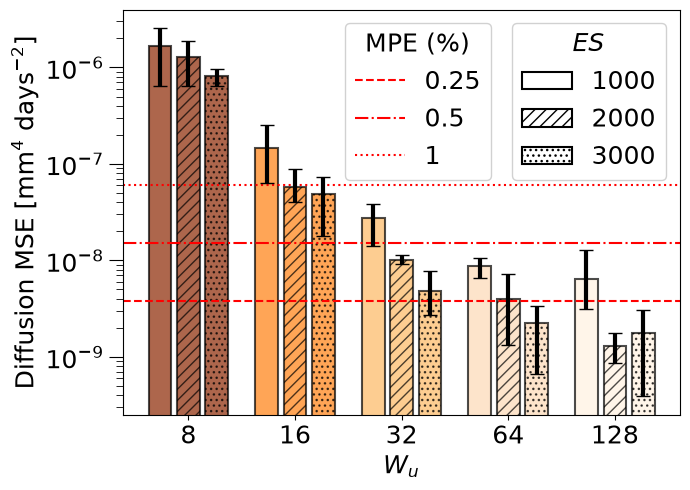

saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/binn-hyperparam-selection/Training/JN/pngs/1D/case1/fig5/plot_d.png


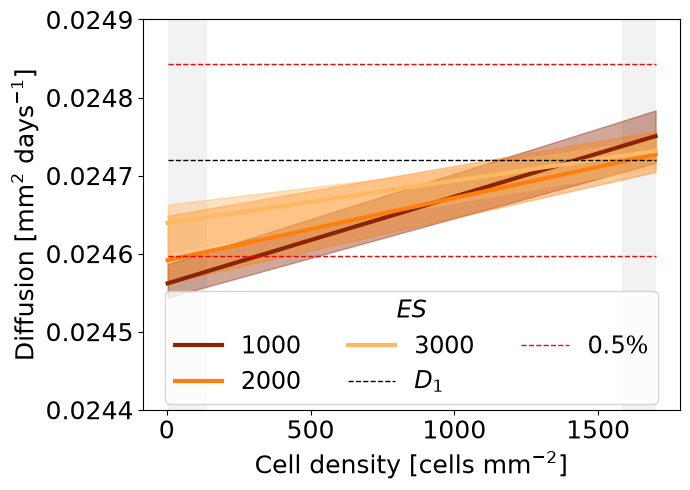

In [9]:
# Diffusion-function comparisons for Sweep A.
diffusion_models_by_es = {
    binn_es: vary_wu_models_by_es[binn_es][SELECTED_D_WIDTH][SELECTED_U_WIDTH]
    for binn_es in VARY_WU_CONFIG["es_values"]
}
diffusion_labels_by_es = [str(binn_es) for binn_es in diffusion_models_by_es.keys()]
diffusion_symbolic_truths_by_es = [
    symbolic_from_function(reference_diffusion_callable)
    for _ in diffusion_labels_by_es
]



# Plot features for figure 5 and figure 7
pde_label_list_fig5_fig7 = [f"{mse}" for mse in RAW_MSES]

# Plot features for figure 7
diffusion_colors_fig7 = D_COLORS

diff_plot_settings = {
    "name": str(figure_7_dir / "plot_a"),
    "fill": True,
    "line_width": 2,
    "grid": False,
    "legend": {
        "panel": 2,
        "loc": (0.35, 1.03),
        "loc_upd": (0.02, 0.42),
        "fontsize": LEGEND_SIZE_SMALL,
        "ncols": 2,
        "framealpha": 0.2,
    },
    "xaxis": X_AXIS,
    "fontsizes": AXIS_FONTSIZES,
    "ylim": (5e-10, 0.6e-2),
    "ylabel": "Minimum diffusion MSE [mm$^4$day$^{-2}$]",
}



# First plot of figure 7
# ======================
plot_running_min_MSE_diff_loss_broken_x_log_lst(
    models_dics_list=models_by_es_for_selected_d_width,
    plot_params=primary_plot_params_fig7,
    plot_settings=diff_plot_settings,
)

# Second plot of figure 7
# ======================
plot_diff_mse_lst(
    models_dics_list=models_by_es_for_selected_d_width,
    plot_params=primary_plot_params_fig7,
    label_list=primary_legend_labels_fig5_fig7,
    name=str(figure_7_dir / "plot_b"),
    colors=diffusion_colors_fig7,
    bbox_to_anchor=(0.675, 1),
    legend_size=LEGEND_SIZE,
    legend_title="$ES$",
    pe_bbox_to_anchor_offset=(-0.3, 0.0),
    pe_label_list=pde_label_list_fig5_fig7,
    pe_legend_title="MPE (%)",
    x_label=r"$W_u$",
    pe_values=REFERENCE_DIFF_MSES,
    axis_fontsizes=AXIS_FONTSIZES,
    hatch_patterns = primary_hatch_patterns_fig5_fig7
)

# third plot of second row of figure 5
# =====================================
plot_eval_D_multi_gray(
    diffusion_models_by_es,
    data_obj,
    diffusion_symbolic_truths_by_es,
    diffusion_colors_fig7,
    diffusion_labels_by_es,
    Dnum=1,
    device="cpu",
    K=REALISTIC_CARRYING_CAPACITY,
    name=str(figure_5_dir / "plot_d.png"),
    fill=True,
    legend_fontsize=LEGEND_SIZE_SMALL,
    legend_title=primary_legend_title_fig5_fig7,
    linestyles=linestyles,
    axis_fontsizes=AXIS_FONTSIZES,
    errs=[0.5, 0.5],
    ylim = [0.0244, 0.0249],
    legend_pos=(0.5, 0.16),
    legend_ncols=3,
)


## 4. Sweep B configuration: vary $W_D$ (and $W_u$) at fixed  $ES = 2000$.

In [10]:
#  ======================== Load models  ======================== 
VARY_WD_CONFIG = {
    "es_values": [2000],
    "d_widths": [1, 2, 4],
    "u_widths": [8, 16, 32, 64, 128],
    "split_seeds": [0, 1, 2],
}

summarize_case1_model_availability(**VARY_WD_CONFIG)
vary_wd_models_by_es = load_case1_models(**VARY_WD_CONFIG)

SELECTED_ES_FOR_VARY_WD = 2000


Requested model combinations: 45
Already trained model files found: 45
Missing model files: 0


All x-axis labels found (ordered): ['8', '16', '32', '64', '128']
saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/binn-hyperparam-selection/Training/JN/pngs/1D/case1/fig5/plot_c_1.png


/Users/willa954/Desktop/Git-personal/Hyperparam/binn-hyperparam-selection/Training/JN/paper_helpers/plotting_final_loss.py:216: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax1.grid(bool(grid), axis="y", which="both", linestyle="-", linewidth=0.5, alpha=grid_alpha)


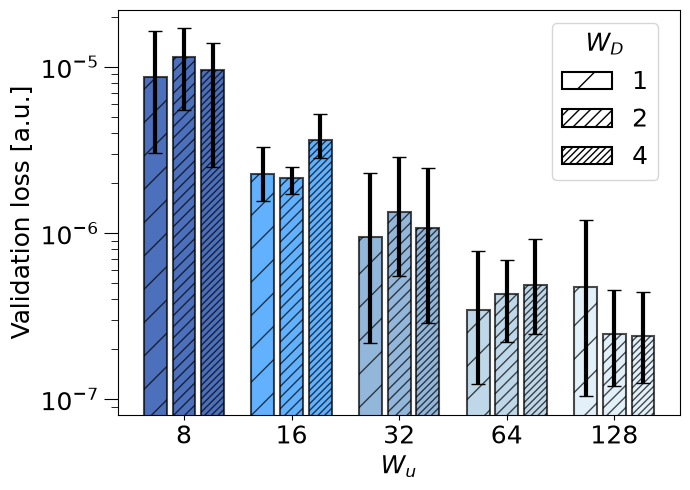

All x-axis labels found (ordered): ['8', '16', '32', '64', '128']
Mean runtime increases between corresponding models across groups:
  1 -> 2
    8: 314.948s -> 258.665s (delta -56.283s)
    16: 317.808s -> 359.175s (delta +41.367s)
    32: 636.535s -> 487.687s (delta -148.848s)
    64: 1079.284s -> 1076.930s (delta -2.354s)
    128: 1180.261s -> 1739.211s (delta +558.951s)
    mean delta: +78.567s
  2 -> 4
    8: 258.665s -> 327.906s (delta +69.241s)
    16: 359.175s -> 284.667s (delta -74.508s)
    32: 487.687s -> 544.272s (delta +56.586s)
    64: 1076.930s -> 986.115s (delta -90.815s)
    128: 1739.211s -> 1557.370s (delta -181.841s)
    mean delta: -44.268s
saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/binn-hyperparam-selection/Training/JN/pngs/1D/case1/fig5/plot_c_2.png


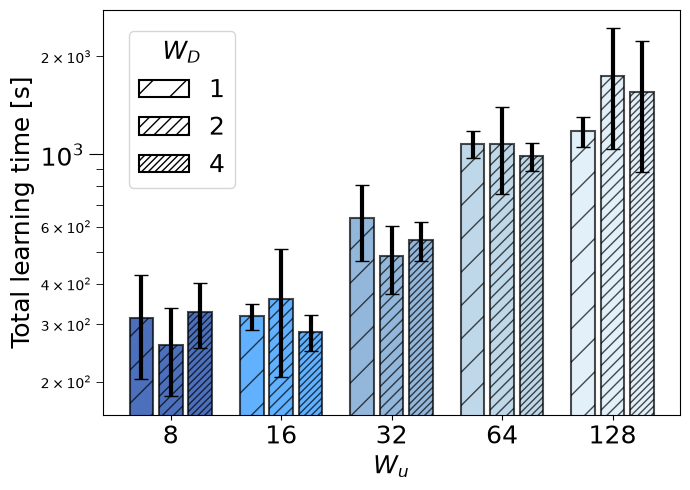

All x-axis labels found (ordered): ['8', '16', '32', '64', '128']
saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/binn-hyperparam-selection/Training/JN/pngs/1D/case1/fig7/plot_c.png


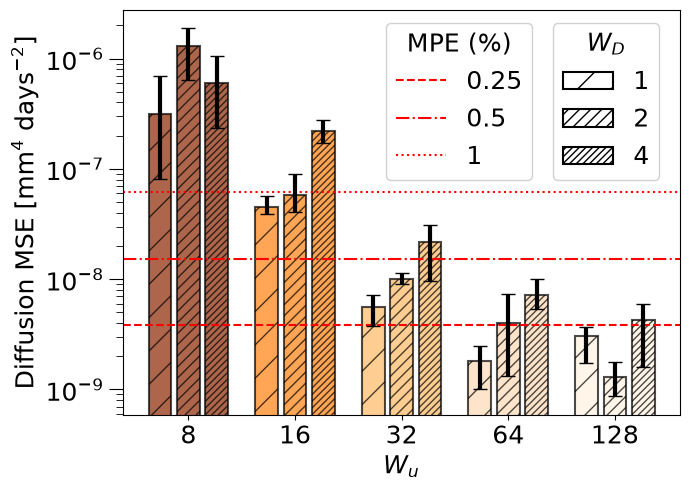

In [11]:
# Models for the selected ES value, varying W_D, for plotting in figure 5 and figure 7
selected_es_models_for_vary_wd = vary_wd_models_by_es[SELECTED_ES_FOR_VARY_WD]
vary_wd_selected_es_list = [
    selected_es_models_for_vary_wd[d_width]
    for d_width in VARY_WD_CONFIG["d_widths"]
]


# Plot features for figure 5 and figure 7
secondary_hatch_patterns_fig5_fig7 = ["/", "///", "/////"]
secondary_legend_title_fig5_fig7 = r"$W_D$"
secondary_legend_labels_fig5_fig7 = [str(d_width) for d_width in VARY_WD_CONFIG["d_widths"]]


# First plot of second row of figure 5
# ====================================
plot_final_loss_lst(
    vary_wd_selected_es_list,
    plot_params=primary_plot_params_fig5,
    label_list=secondary_legend_labels_fig5_fig7,
    name=str(figure_5_dir / "plot_c_1.png"),
    bbox_to_anchor=(0.75, 1),
    legend_size=LEGEND_SIZE,
    legend_title=secondary_legend_title_fig5_fig7,
    x_label=WIDTH_AXIS_LABEL,
     hatch_patterns=secondary_hatch_patterns_fig5_fig7,
     axis_fontsizes=AXIS_FONTSIZES
     
     
)

# Second plot of second row of figure 5
# ====================================
plot_total_run_times_lst(
    models_dics_list=vary_wd_selected_es_list,
    plot_params=primary_plot_params_fig5,
    label_list=secondary_legend_labels_fig5_fig7,
    legend_pos=(0.25, 0.98),
    legend_fontsize=LEGEND_SIZE,
    x_label=WIDTH_AXIS_LABEL,
    name=str(figure_5_dir / "plot_c_2.png"),
    hatch_patterns=secondary_hatch_patterns_fig5_fig7,
    legend_title=secondary_legend_title_fig5_fig7,
    axis_fontsizes=AXIS_FONTSIZES
    
)


# third plot of figure 7
# ======================
plot_diff_mse_lst(
    models_dics_list=vary_wd_selected_es_list,
    plot_params=primary_plot_params_fig7,
    label_list=secondary_legend_labels_fig5_fig7,
    name=str(figure_7_dir / "plot_c.png"),
    colors=D_COLORS,
    bbox_to_anchor=(0.75, 1),
    legend_size=LEGEND_SIZE,
    legend_title=secondary_legend_title_fig5_fig7,
    pe_bbox_to_anchor_offset=(-0.3, 0.0),
    pe_label_list=[f"{mse}" for mse in RAW_MSES],
    x_label=WIDTH_AXIS_LABEL,
    hatch_patterns=secondary_hatch_patterns_fig5_fig7,
    pe_values=REFERENCE_DIFF_MSES,
    axis_fontsizes=AXIS_FONTSIZES
)


## References

J. H. Lagergren et al. "Biologically-informed neural networks guide mechanistic modeling from sparse experimental data". In: *PLoS Comput Biol* 16.12 (2020), e1008462. DOI: [10.1371/journal.pcbi.1008462](https://doi.org/10.1371/journal.pcbi.1008462).
